<a href="https://colab.research.google.com/github/rochita-06/machine-learning-project/blob/main/knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving diabetes.csv to diabetes.csv
Dataset loaded successfully!
Shape: (2000, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0



========== KNN RESULTS ==========
K value: 5
Accuracy: 0.8175
Precision: 0.7388059701492538
Recall: 0.7226277372262774
F1 Score: 0.7306273062730627

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       263
           1       0.74      0.72      0.73       137

    accuracy                           0.82       400
   macro avg       0.80      0.79      0.80       400
weighted avg       0.82      0.82      0.82       400



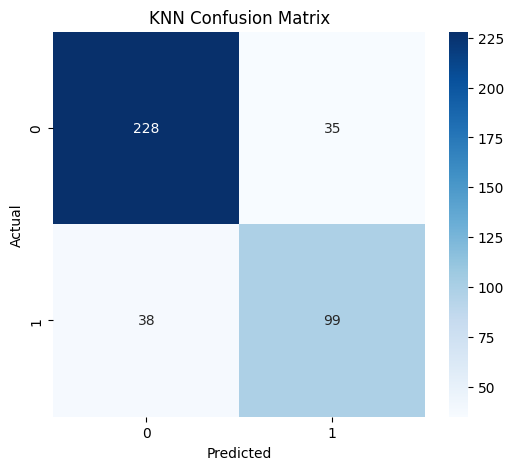

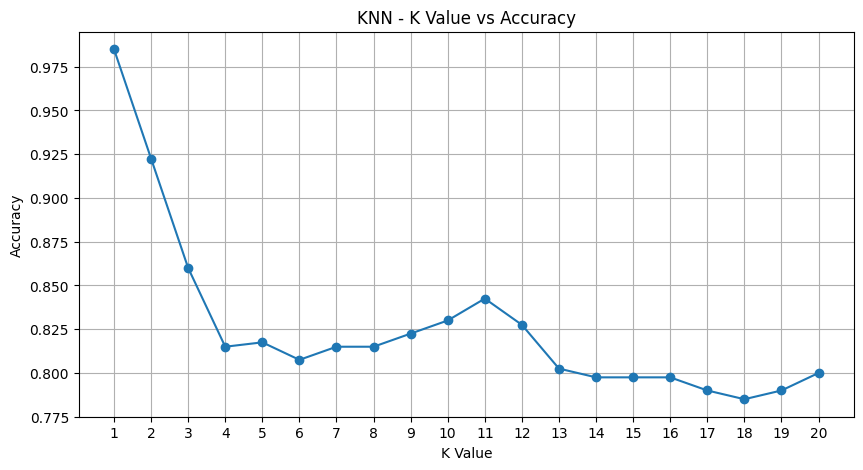

Best K: 1
Best Accuracy: 0.985


In [1]:
# ==========================================
# KNN CLASSIFICATION - DIABETES DATASET
# ==========================================

# Upload dataset
from google.colab import files
uploaded = files.upload()

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Read uploaded file
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())

# Separate features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Replace invalid zero values
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

X[zero_columns] = X[zero_columns].replace(0, np.nan)

# Fill missing values
imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create KNN model
k = 5

model = KNeighborsClassifier(n_neighbors=k)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("\n========== KNN RESULTS ==========")

print("K value:", k)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall:",
      recall_score(y_test, y_pred))

print("F1 Score:",
      f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

# Find best K
k_values = range(1, 21)
accuracies = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    prediction = knn.predict(X_test)

    accuracies.append(
        accuracy_score(y_test, prediction)
    )

# Plot K vs Accuracy
plt.figure(figsize=(10,5))

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN - K Value vs Accuracy")
plt.xticks(k_values)
plt.grid()

plt.show()

best_k = k_values[np.argmax(accuracies)]

print("Best K:", best_k)
print("Best Accuracy:", max(accuracies))